In [6]:
from agent.dqn_agent import DQN_Agent
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
import numpy as np

from config.config_loader import load_config

In [7]:
config = load_config()
    
params = config['hyperparameters']

In [8]:
# Create the environment
env_sb3 = gym.make("LunarLander-v3")
env_sb3 = Monitor(env_sb3)

# Instantiate the agent
model = DQN("MlpPolicy", 
            env_sb3, 
            verbose=0, 
            buffer_size=params['buffer_size'],
            batch_size=params['batch_size'],
            train_freq=params['train_freq'], 
            gamma=params["gamma"], 
            exploration_fraction=0.5,
            exploration_initial_eps=1,
            exploration_final_eps=0.1, 
            target_update_interval=params['target_update'], 
            learning_rate=params['alpha'],
            )

# Train the agent
model.learn(total_timesteps=100_000) # Documentation uses 1_000_000
sb3_rewards = env_sb3.get_episode_rewards()
env_sb3.close()

In [9]:
env = gym.make("LunarLander-v3")

agent = DQN_Agent(
    observation_space=env.observation_space,
    action_space=env.action_space,
    replay_buffer_size=params['buffer_size'],
    batch_size=params['batch_size'],
    alpha=params['alpha'],
    gamma=params['gamma'],
    initial_epsilon=1.0,
    final_epsilon=0.1,
    epsilon_decay=params['epsilon_decay'],
    C=params['target_update'],
    train_freq=params['train_freq']
)

returns = agent.train(env, len(sb3_rewards))
env.close()

Episode 100/317 - Return: -66.71 - Epsilon: 0.9058
Episode 200/317 - Return: -76.93 - Epsilon: 0.8205
Episode 300/317 - Return: -91.88 - Epsilon: 0.7433


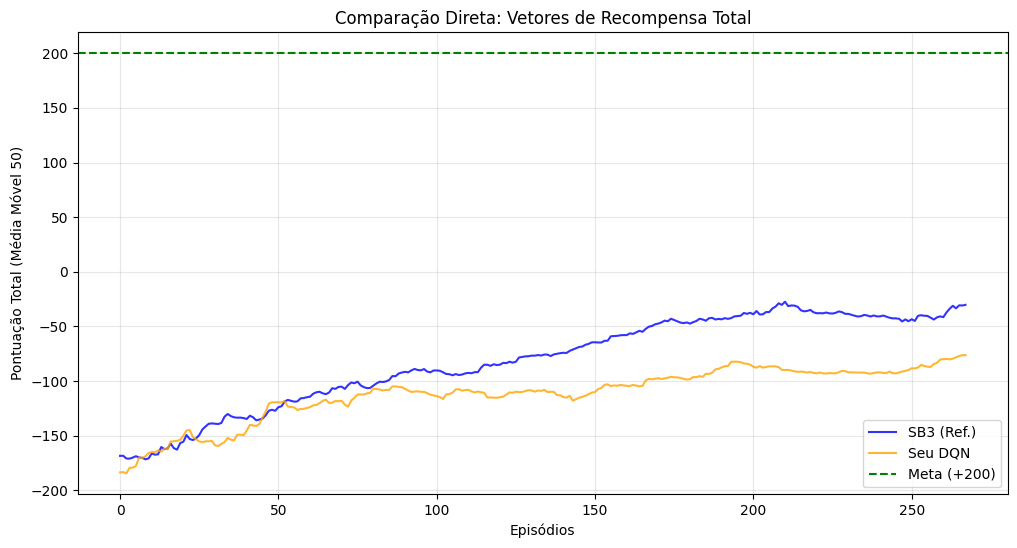

In [10]:
def moving_average(values, window=50):
    return np.convolve(values, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 6))

# Plot SB3
plt.plot(moving_average(sb3_rewards), label="SB3 (Ref.)", color="blue", alpha=0.8)

# Plot Seu Modelo
plt.plot(moving_average(returns), label="Seu DQN", color="orange", alpha=0.8)

plt.axhline(200, color="green", linestyle="--", label="Meta (+200)")
plt.title("Comparação Direta: Vetores de Recompensa Total")
plt.xlabel("Episódios")
plt.ylabel("Pontuação Total (Média Móvel 50)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()